In [4]:
import tensorflow as tf
import pandas as pd
import os
import numpy as np

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense,Bidirectional 
from tensorflow.keras.preprocessing.text import Tokenizer 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.optimizers import Adam


In [5]:
df=pd.read_csv(r"data\medium_data.csv")
df.sample(5)

,id,url,title,subtitle,image,claps,responses,reading_time,publication,date
902,903,https://uxdesign.cc/how-to-create-product-cont...,How To: create product content guidelines,What are content guidelines? How do you create...,903.png,344,4,5,UX Collective,2019-04-22
4758,4759,https://medium.com/swlh/7-steps-i-follow-for-d...,7 Steps I follow for developing a Device Driver,NaN,4759.jpeg,51,0,5,The Startup,2019-12-20
2922,2923,https://medium.com/swlh/breaking-through-the-a...,Breaking Through the “Always On” Mentality,NaN,2923.jpg,250,1,3,The Startup,2019-11-08
3811,3812,https://medium.com/better-marketing/reusing-an...,Reusing and Upcycling Materials Is Getting a M...,The brands and product designers making…,3812.jpeg,63,1,3,Better Marketing,2019-08-08
5669,5670,https://medium.com/swlh/3-habits-to-maximize-s...,3 Habits To Maximize Success,And grow every day,5670.jpg,65,1,5,The Startup,2019-07-28


In [6]:
display(df.shape)

(6508, 10)

In [7]:
df['title']

0       A Beginner’s Guide to Word Embedding with Gens...
1       Hands-on Graph Neural Networks with PyTorch & ...
2                            How to Use ggplot2 in Python
3       Databricks: How to Save Files in CSV on Your L...
4       A Step-by-Step Implementation of Gradient Desc...
                              ...                        
6503    “We” vs “I” — How Should You Talk About Yourse...
6504                     How Donald Trump Markets Himself
6505        Content and Marketing Beyond Mass Consumption
6506    5 Questions All Copywriters Should Ask Clients...
6507               How To Write a Good Business Blog Post
Name: title, Length: 6508, dtype: object

In [8]:
df['title']=df['title'].apply(lambda x:x.replace(u'\xa0',u' ')) # removing  Non-Breaking Space
df['title']=df['title'].apply(lambda x:x.replace('\u200a',' ')) #Hair Space. very thin space  which can be visually indistinguishable from regular spaces 

Handling OOV Words: The use of an OOV token allows the model to gracefully handle words that were not present in the training data, which is important for generalization when the model encounters new or rare words during inference.

In [9]:
tokenizer = Tokenizer(oov_token='<oov>') # For those words which are not found in word_index
tokenizer.fit_on_texts(df['title'])
total_words=len(tokenizer.word_index)+1
print('total words:',len(tokenizer.word_index)+1)
print('<oov>', tokenizer.word_index['<oov>'])
print('strong',tokenizer.word_index['strong'])
print('consumption: ', tokenizer.word_index['consumption'])


total words: 8238
<oov> 1
strong 4
consumption:  8237


Using n-grams in this context helps to create sequences that capture the relationships between words in the titles. This is particularly useful for training language models that need to understand the context of words in order to make predictions about subsequent words in a sequence. The generated input_sequences can be used as training data for such models.

In [10]:
input_sequences = []
for line in df['title']:
    token_list=tokenizer.texts_to_sequences([line])[0]
    
    for x in range(len(token_list)):
        n_gram=token_list[:x+1]
        input_sequences.append(n_gram)
        
        
# print(input_sequences)
print("Total input sequences: ", len(input_sequences))

    


Total input sequences:  54969


In [11]:
# pad sequences 
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = (pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))
input_sequences



array([[  0,   0,   0, ...,   0,   0,   5],
       [  0,   0,   0, ...,   0,   5, 676],
       [  0,   0,   0, ...,   5, 676,  68],
       ...,
       [  0,   0,   0, ...,   5,  85,  56],
       [  0,   0,   0, ...,  85,  56, 730],
       [  0,   0,   0, ...,  56, 730, 550]])

In [12]:
X_features, label=input_sequences[:,:-1],input_sequences[:,-1]

y_target= tf.keras.utils.to_categorical(label, num_classes=total_words) 


In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import gc  # Garbage Collector for memory management

# --- STEP 1: LOAD GLOVE VECTORS ---
glove_path = 'glove.6B.100d.txt' 
embeddings_index = {}

print("Reading GloVe vectors...")
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

# --- STEP 2: CREATE EMBEDDING MATRIX ---
embedding_dim = 100 
embedding_matrix = np.zeros((total_words, embedding_dim))

for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Clear memory: delete the raw dictionary once the matrix is built
del embeddings_index
gc.collect()
print("Embedding matrix created and memory cleared.")

# --- STEP 3: BUILD MODEL ---
model = Sequential()

# Using the GloVe matrix weights and setting trainable=True
model.add(Embedding(
    input_dim=total_words, 
    output_dim=embedding_dim,        
    weights=[embedding_matrix],      
    input_length=max_sequence_len - 1, 
    trainable=True                   
))

model.add(SpatialDropout1D(0.2))
model.add(Bidirectional(LSTM(150)))
model.add(Dense(total_words, activation='softmax'))

model.compile(
    optimizer='adam',
    metrics=['accuracy'],
    loss='categorical_crossentropy'
)

model.summary()

# --- STEP 4: TRAIN MODEL ---
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

print("Starting training...")
history = model.fit(
    X_features, 
    y_target,
    epochs=50,             # High limit, EarlyStopping will handle the rest
    batch_size=64,         
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Reading GloVe vectors...
Found 400001 word vectors.
Embedding matrix created and memory cleared.


c:\Users\mina\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       823,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 823,800 (3.14 MB)

 Trainable params: 823,800 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.0587 - loss: 7.3285 - val_accuracy: 0.1227 - val_loss: 6.6153
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 45s 65ms/step - accuracy: 0.1329 - loss: 6.1656 - val_accuracy: 0.1464 - val_loss: 6.4294
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 49s 72ms/step - accuracy: 0.1587 - loss: 5.6551 - val_accuracy: 0.1537 - val_loss: 6.4033
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.1732 - loss: 5.3098 - val_accuracy: 0.1651 - val_loss: 6.4337
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 49s 71ms/step - accuracy: 0.1907 - loss: 4.9501 - val_accuracy: 0.1703 - val_loss: 6.4826
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 49s 72ms/step - accuracy: 0.2068 - loss: 4.6397 - val_accuracy: 0.1651 - val_loss: 6.5443
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.2309 - loss: 4.3628 - val_accuracy: 0.1710 - val_loss: 6.6276
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.2

In [14]:
import matplotlib.pyplot as plt

def graph(history, string):
    plt.plot(history.history[string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.show() 

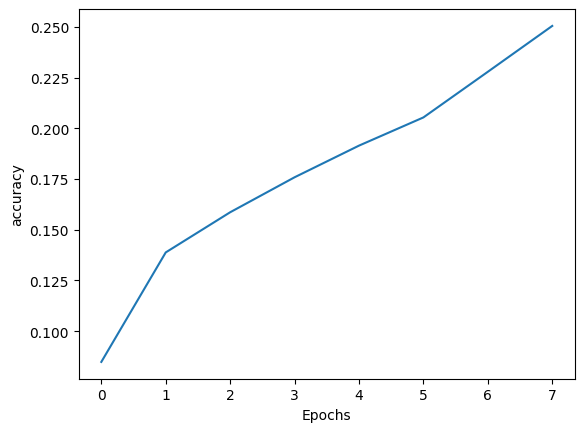

In [15]:
graph(history, 'accuracy')


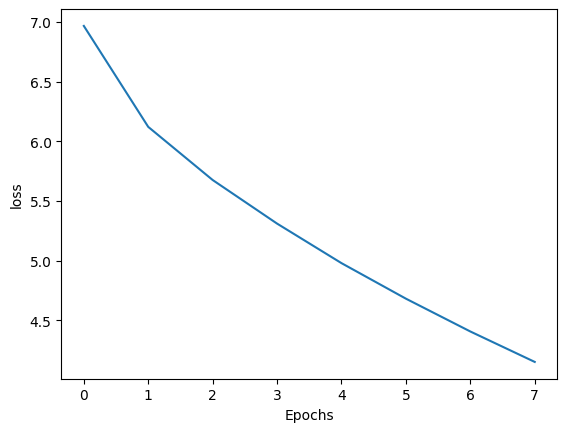

In [16]:
graph(history, 'loss')


In [17]:
def predict_next_words(seed_text, next_words=3, temperature=0.5):
    for _ in range(next_words):
        # 1. Tokenize the input string
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        # 2. Pad the sequence
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
        
        # 3. Get predictions (probabilities for all words)
        predictions = model.predict(token_list, verbose=0)[0]
        
        # 4. Apply Temperature Scaling
        # Lower temp (0.2) = more confident/predictable
        # Higher temp (1.0) = more creative/random
        predictions = np.log(predictions + 1e-7) / temperature
        exp_preds = np.exp(predictions)
        predictions = exp_preds / np.sum(exp_preds)
        
        # 5. Pick the next word based on the new probabilities
        predicted_index = np.random.choice(len(predictions), p=predictions)
        
        # 6. Convert the index back to a word
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

# --- TEST IT OUT ---
print("\n--- Model Testing ---")
test_phrase = "AI is"
result = predict_next_words(test_phrase, next_words=4, temperature=0.3)
print(f"Result: {result}")


--- Model Testing ---
Result: AI is a ux case study


In [18]:
# Save the model
model.save('autocomplete_model.h5')

# Save the tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Model and Tokenizer saved successfully!")

Model and Tokenizer saved successfully!
